In [17]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.2 MB 9.7 MB/s eta 0:00:01
   ----------- ---------------------------- 2.4/8.2 MB 6.5 MB/s eta 0:00:01
   ---------------- ----------------------- 3.4/8.2 MB 5.7 MB/s eta 0:00:01
   --------------------- ------------------ 4.5/8.2 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 7.9 MB/s  0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 19.7 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----------- ---------------------


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.7 MB 12.2 MB/s eta 0:00:01
   ------------------------------------- -- 9.2/9.7 MB 23.9 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 21.1 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd

file_path = "Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
print(df.shape)
print("--------------------------------------------------------------------------------------------")
print(df.columns)
print("--------------------------------------------------------------------------------------------")
print(df.info())

(7043, 21)
--------------------------------------------------------------------------------------------
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')
--------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    


In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [10]:
df = df.dropna()

In [11]:
df = df.drop_duplicates()

In [12]:
def tenure_group(x):
    if x <= 12:
        return "0-1 Year"
    elif x <= 24:
        return "1-2 Years"
    elif x <= 48:
        return "2-4 Years"
    else:
        return "4+ Years"

df['tenure_group'] = df['tenure'].apply(tenure_group)

In [13]:
df['charge_group'] = pd.cut(df['MonthlyCharges'],
                           bins=[0, 30, 60, 90, 120],
                           labels=['Low', 'Medium', 'High', 'Very High'])

In [14]:
df['high_risk'] = ((df['Contract'] == 'Month-to-month') & (df['tenure'] < 12)).astype(int)

In [15]:
df.to_csv("cleaned_churn_data.csv", index=False)

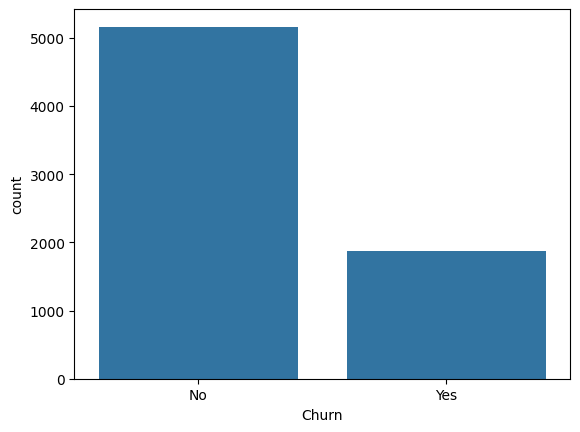

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.show()